# **J3 - Deep Learning pour les codeurs**

## **Application de l’apprentissage profond : Introduction**

1. Un jeu de données appelé *Oxford-IIIT Pet Dataset*, contenant 7 349 images de chats et de chiens appartenant à 37 races, sera téléchargé depuis la collection de jeux de données de fast.ai sur le serveur GPU que vous utilisez, puis décompressé.

2. Un modèle préentraîné, entraîné sur 1,3 million d’images et issu d’une architecture ayant remporté un concours, sera téléchargé depuis Internet.

3. Ce modèle sera affiné à l’aide des dernières avancées en apprentissage par transfert afin de reconnaître spécifiquement les chats et les chiens.

In [2]:
from fastai.vision.all import *

In [9]:
import ipywidgets as widgets

In [2]:
path = untar_data(URLs.PETS)/'images'

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:14&lt;00:00]</div>

In [3]:
def is_cat(x): return x[0].isupper()

In [4]:
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224))

### **ResNet-34**

**ResNet-34** signifie « réseau résiduel à 34 couches ». C’est un réseau de neurones convolutif utilisé notamment pour classer des images.

Son idée centrale est la **connexion de saut** : au lieu de faire passer l’information uniquement à travers une série de convolutions, un bloc ajoute aussi son entrée à sa sortie, selon le principe $y = F(x) + x$. Cela facilite l’entraînement d’un réseau profond.

ResNet-34 organise ses blocs résiduels en quatre groupes de 3, 4, 6 et 3 blocs ; chaque bloc de base comporte deux convolutions $3 \times 3$.

In [5]:
learn = cnn_learner(dls, resnet34, metrics=error_rate)

/usr/local/lib/python3.13/dist-packages/fastai/vision/learner.py:304: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 213MB/s]


In [6]:
learn.fine_tune(1)

epoch,train_loss,valid_loss,error_rate,time
0,0.165951,0.022011,0.007442,00:26


epoch,train_loss,valid_loss,error_rate,time
0,0.051880,0.019344,0.005413,00:33


In [12]:
uploader = widgets.FileUpload()
uploader

FileUpload(value={}, description='Upload')

In [13]:
img = PILImage.create(uploader.data[0])
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: False.
Probability it's a cat: 0.000000


## **Autre applications du Deep Learning**

### **Exemple d’application : La segmentation d'images**

Abordons une tâche cruciale pour les véhicules autonomes : la localisation précise des objets dans une image. Si une voiture autonome ne sait pas exactement où se trouve un piéton, elle ne peut pas l'éviter !

L'entraînement d'un modèle capable de reconnaître et de catégoriser le contenu de **chaque pixel individuel** d'une image s'appelle la **segmentation d'images** (ou segmentation sémantique).

Voici comment entraîner un modèle de segmentation avec *fastai* en utilisant un sous-ensemble du jeu de données **CamVid** issu de l'article *« Semantic Object Classes in Video: A High-Definition Ground Truth Database »* de Gabriel J. Brostow et al. :

In [3]:
path = untar_data(URLs.CAMVID_TINY)

<div><progress max="2314212" value="2318336"></progress> 100.18% [2318336/2314212 00:01&lt;00:00]</div>

In [4]:
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt', dtype=str)
)

In [5]:
learn = unet_learner(dls, resnet34)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 152MB/s]


In [6]:
learn.fine_tune(8)

epoch,train_loss,valid_loss,time
0,2.734755,14.123057,00:02


epoch,train_loss,valid_loss,time
0,3.067320,2.120139,00:01
1,2.283039,1.511174,00:01
2,1.899415,1.253281,00:01
3,1.632489,1.127353,00:01
4,1.426634,0.972756,00:01
5,1.254031,0.933304,00:01
6,1.119007,0.882463,00:01
7,1.017372,0.877818,00:01


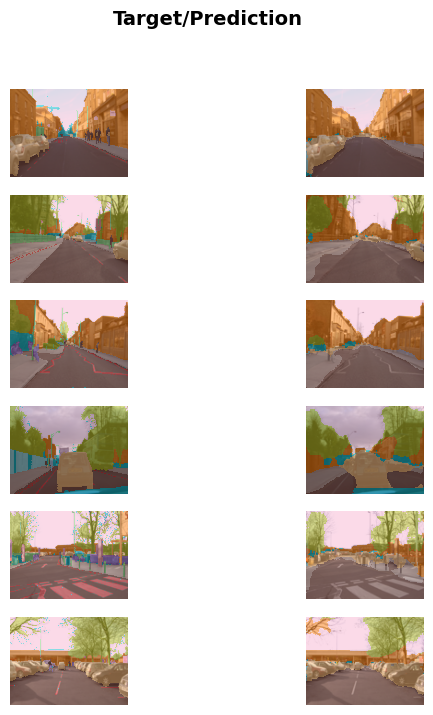

In [7]:
learn.show_results(max_n=6, figsize=(7,8))

#### **Détails techniques : Segmentation avec U-Net**

* **`unet_learner`** : Crée un réseau d'architecture **U-Net** (très populaire pour la segmentation sémantique). L'encodeur (la partie descendante) est ici un `resnet34` préentraîné qui extrait les caractéristiques de l'image. Le décodeur (la partie montante) reconstruit l'image pour prédire la classe de chaque pixel.
* **`SegmentationDataLoaders`** : Charge les images et associe à chacune son masque de segmentation (la vérité terrain qui indique la catégorie de chaque pixel) à l'aide de la fonction `label_func`.

### **Exemple d’application : NLP**

One other area where deep learning has dramatically improved in the last couple of years is natural language processing (NLP). Computers can now generate text, translate automatically from one language to another, analyze comments, label words in sentences, and much more. Here is all of the code necessary to train a model that can classify the sentiment of a movie review better than anything that existed in the world just five years ago:



In [9]:
from fastai.text.all import *

In [10]:
dls = TextDataLoaders.from_folder(untar_data(URLs.IMDB), valid='test')

<div><progress max="144440600" value="144441344"></progress> 100.00% [144441344/144440600 00:10&lt;00:00]</div>

#### **Définition ULMFiT**

`ULMFiT` (**Universal Language Model Fine-tuning**) est une méthode d'apprentissage par transfert pour le NLP, proposée par Howard et Ruder en 2018. Elle s'applique à n'importe quelle tâche de classification de texte. Elle s'inspire de ce que le préentraînement ImageNet avait apporté à la vision. C'est l'une des premières méthodes à utiliser un modèle de langage génératif préentraîné, puis affiné sur une tâche précise.


#### **Le rôle d'AWD-LSTM**
`AWD-LSTM` est le réseau de base d'`ULMFiT`. Dans l'implémentation d'origine, c'est un réseau à `3 couches`, avec des `embeddings de taille 400` et `1 152 unités cachées par couche`. Ses dropouts (dont le `DropConnect` sur les poids récurrents) `protègent contre le surapprentissage` quand on affine sur un petit jeu de données.


#### **Détails techniques : NLP & Classification de sentiments**

* **`TextDataLoaders`** : Prépare les données textuelles en effectuant automatiquement la **tokenisation** (découpage du texte en mots ou sous-mots) et la **numérisation** (conversion des tokens en identifiants numériques).
* **`text_classifier_learner`** : Instancie un classifieur de texte basé sur l'architecture récurrente `AWD_LSTM`. Le paramètre `drop_mult` ajuste l'intensité de la régularisation par dropout pour éviter le surapprentissage sur le texte.

In [11]:
learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:07&lt;00:00]</div>

In [12]:
learn.fine_tune(4, 1e-2)

epoch,train_loss,valid_loss,accuracy,time
0,0.463862,0.408835,0.815400,03:45


epoch,train_loss,valid_loss,accuracy,time
0,0.319163,0.306326,0.873680,07:58
1,0.236578,0.200355,0.922320,07:58
2,0.195052,0.190765,0.925040,07:59


epoch,train_loss,valid_loss,accuracy,time
0,0.319163,0.306326,0.873680,07:58
1,0.236578,0.200355,0.922320,07:58
2,0.195052,0.190765,0.925040,07:59
3,0.153195,0.189589,0.928400,07:59


In [13]:
learn.predict("I really liked that movie!")

('pos', tensor(1), tensor([1.9089e-04, 9.9981e-01]))

In [14]:
learn.predict("Is William have appreaciated the way that ULMFiT have been learned")

('pos', tensor(1), tensor([0.0263, 0.9737]))

In [15]:
learn.predict("I hate machine learning")

('neg', tensor(0), tensor([0.5256, 0.4744]))

### **Exemple d’application : Données tabulaires (Tabular Dataset)**

Ce modèle utilise le jeu de données *Adult*, issu de l'article *« Scaling Up the Accuracy of Naive-Bayes Classifiers: a Decision-Tree Hybrid »* de Ron Kohavi. Il contient des données démographiques anonymisées sur des individus (telles que le niveau d'éducation, le statut marital, l'origine ethnique, le sexe, et si leur revenu annuel dépasse ou non 50 000 $).

L'apprentissage sur ce type de données structurées permet de faire des prédictions rapides. Ici, le modèle obtient une précision de plus de 80 % en quelques dizaines de secondes d'entraînement.

In [16]:
from fastai.tabular.all import *

In [17]:
path = untar_data(URLs.ADULT_SAMPLE)

<div><progress max="968212" value="974848"></progress> 100.69% [974848/968212 00:01&lt;00:00]</div>

In [18]:
dls = TabularDataLoaders.from_csv(
    path/'adult.csv', path=path, y_names="salary",
    cat_names =
      [
          'workclass', 'education', 'marital-status', 'occupation','relationship', 'race'
      ],
    cont_names = ['age', 'fnlwgt', 'education-num'],
    procs = [Categorify, FillMissing, Normalize]
)

In [19]:
learn = tabular_learner(dls, metrics=accuracy)

In [20]:
learn.fit_one_cycle(3)

epoch,train_loss,valid_loss,accuracy,time
0,0.378156,0.357477,0.834613,00:04
1,0.353943,0.351607,0.837070,00:04
2,0.352698,0.350500,0.836302,00:04


In [21]:
# Affichage de quelques résultats du modèle tabulaire pour analyser ses prédictions
learn.show_results()

,workclass,education,marital-status,occupation,relationship,race,education-num_na,age,fnlwgt,education-num,salary,salary_pred
0,5.0,16.0,3.0,0.0,1.0,5.0,2.0,0.472373,-0.553095,-0.034901,0.0,0.0
1,5.0,12.0,3.0,4.0,1.0,5.0,1.0,-0.040857,-0.429160,-0.426606,0.0,0.0
2,5.0,16.0,5.0,13.0,3.0,5.0,1.0,-1.287273,-0.487087,-0.034901,0.0,0.0
3,5.0,16.0,3.0,12.0,1.0,4.0,1.0,0.325735,0.253909,-0.034901,0.0,1.0
4,5.0,16.0,5.0,2.0,2.0,3.0,1.0,-1.067317,0.493145,-0.034901,0.0,0.0
5,5.0,9.0,5.0,9.0,4.0,5.0,1.0,-1.287273,-0.652165,0.356803,0.0,0.0
6,5.0,12.0,3.0,8.0,1.0,5.0,1.0,1.058921,-0.569098,-0.426606,0.0,0.0
7,8.0,10.0,3.0,11.0,1.0,5.0,1.0,1.718788,-1.429750,1.140212,0.0,1.0
8,5.0,12.0,1.0,2.0,2.0,5.0,1.0,0.325735,2.561123,-0.426606,0.0,0.0


#### **Détails techniques : Modèles Tabulaires**

* **`TabularDataLoaders`** : Gère automatiquement les colonnes catégorielles (`cat_names`) et continues (`cont_names`). Les préprocesseurs appliqués sont :
  * `Categorify` : Transforme les variables textuelles/catégorielles en catégories numériques.
  * `FillMissing` : Gère les valeurs manquantes en les remplaçant par la médiane et crée une colonne booléenne indicatrice.
  * `Normalize` : Centre et réduit les variables continues pour faciliter la convergence.
* **`tabular_learner`** : Crée par défaut un réseau de neurones multicouche entièrement connecté (MLP) adapté aux données tabulaires.

### **Exemple d’application : Système de recommandation**

Les systèmes de recommandation sont essentiels, en particulier pour le commerce électronique et les plateformes de streaming. Des entreprises comme Amazon ou Netflix s'efforcent de suggérer des produits ou des films adaptés aux goûts de leurs utilisateurs.

Voici comment entraîner un modèle capable de prédire les films qu'un utilisateur pourrait apprécier en se basant sur ses habitudes de visionnage passées, en utilisant le jeu de données **MovieLens** :

In [22]:
from fastai.collab import *

In [23]:
path = untar_data(URLs.ML_SAMPLE)

<div><progress max="51790" value="57344"></progress> 110.72% [57344/51790 00:00&lt;00:00]</div>

In [24]:
dls = CollabDataLoaders.from_csv(path/'ratings.csv')

In [25]:
learn = collab_learner(dls, y_range=(0.5,5.5))

In [26]:
learn.fine_tune(10)

epoch,train_loss,valid_loss,time
0,1.485938,1.457049,00:00


epoch,train_loss,valid_loss,time
0,1.372380,1.402564,00:00
1,1.277815,1.245160,00:00
2,1.060745,0.951140,00:00
3,0.820077,0.790671,00:00
4,0.708743,0.745347,00:00
5,0.647091,0.725735,00:00
6,0.596039,0.716932,00:00
7,0.589954,0.715050,00:00
8,0.580275,0.713587,00:00
9,0.566122,0.713463,00:00


In [27]:
learn.show_results()

,userId,movieId,rating,rating_pred
0,63.0,47.0,4.0,3.164370
1,9.0,36.0,3.0,3.275317
2,59.0,97.0,4.0,4.239314
3,16.0,44.0,2.0,3.159462
4,4.0,57.0,4.5,4.333048
5,89.0,48.0,3.5,4.019011
6,28.0,25.0,2.0,3.058382
7,22.0,57.0,4.0,3.730462
8,70.0,91.0,3.0,4.173653


#### **Détails techniques : Filtrage collaboratif (Recommandation)**

* **`CollabDataLoaders`** : Prépare la matrice d'interactions utilisateurs-items à partir d'un format de liste de notations (ratings).
* **`collab_learner`** : Construit un modèle basé sur la **factorisation de matrice** (ou un réseau de neurones simple). Il apprend des vecteurs de caractéristiques latentes (embeddings) pour chaque utilisateur et chaque film. Le paramètre `y_range` contraint la prédiction finale à rester dans les bornes réelles des notes (ici entre 0.5 et 5.5).

## **Atelier Pratique : Cas d'Usage Étudiant**

Dans cet atelier guidé étape par étape, vous allez choisir un jeu de données de la bibliothèque *fastai* et implémenter votre propre modèle. Suivez attentivement les consignes ci-dessous.

### **Étape 1 : Choix de votre sujet et téléchargement des données**

Sélectionnez **un seul** des scénarios suivants :
*   **A (Vision - Classification)** : Utiliser le jeu de données `URLs.MNIST_TINY` pour classifier des chiffres manuscrits.
*   **B (NLP - Classification)** : Utiliser un petit échantillon de texte avec `URLs.YELP_REVIEWS_SUBSET` pour classifier des avis.
*   **C (Données Tabulaires)** : Réutiliser `URLs.ADULT_SAMPLE` ou un autre tableau de votre choix pour prédire une variable cible.

* **D (Au choix)** : Vous pouvez avoir utiliser n'importe quel type ou set de données tout dépend de vous sur ce choix.

In [ ]:
# ÉTAPE 1 : Décommentez et exécutez la ligne correspondant à votre choix de dataset

# Choix A (Chiffres manuscrits - Vision):
# path = untar_data(URLs.MNIST_TINY)

# Choix B (Avis clients - NLP):
# path = untar_data(URLs.YELP_REVIEWS_SUBSET)

# Exemple par défaut (Choix A) :
path = untar_data(URLs.MNIST_TINY)
print(f"Données prêtes et stockées dans : {path}")

### **Étape 2 : Préparation des DataLoaders**

Construisez l'objet `DataLoaders` adapté à votre choix de données afin que le modèle puisse les consommer.

In [ ]:
# ÉTAPE 2 : Préparez vos données avec les DataLoaders de fastai
# Pour l'exemple MNIST_TINY (classification d'images) :

dls = ImageDataLoaders.from_folder(path, valid_pct=0.2, item_tfms=Resize(28))

# Affichez un lot pour vérifier que l'importation s'est bien déroulée
dls.show_batch(max_n=4, nrows=1)

### **Étape 3 : Définition et entraînement du modèle (Fine-tuning)**

Instanciez le `learner` adéquat (par exemple `vision_learner` ou `text_classifier_learner`) et lancez un entraînement court avec `fine_tune` ou `fit_one_cycle`.

In [ ]:
# ÉTAPE 3 : Instanciation et entraînement
learn = vision_learner(dls, resnet18, metrics=accuracy)

# Entraînement sur 2 époques
learn.fine_tune(2)

### **Étape 4 : Analyse et prédiction**

Affichez les premiers résultats visuels de votre modèle et testez-le sur une nouvelle prédiction individuelle de votre choix.

In [ ]:
# ÉTAPE 4 : Interprétation
learn.show_results(max_n=4)

# Faites une prédiction sur un fichier de test individuel si disponible
files = get_image_files(path/'test')
if len(files) > 0:
    pred, pred_idx, probs = learn.predict(files[0])
    print(f"Prédiction pour {files[0].name} : {pred} avec une probabilité de {probs[pred_idx]:.4f}")

### **Étape 5 : Sauvegarder et charger votre modèle pour le futur**

Pour de la mise en production ou pour réutiliser votre modèle plus tard sans avoir à le réentraîner, vous devez l'exporter.

*   **`learn.export('mon_modele.pkl')`** : Sauvegarde l'architecture complète, la configuration du DataLoader (comme la correspondance des classes) et les poids entraînés du modèle dans un fichier sérialisé.
*   **`load_learner('mon_modele.pkl')`** : Permet de recharger le modèle instantanément sur n'importe quelle machine disposant de PyTorch et fastai.

In [ ]:
# Sauvegarder le modèle dans un fichier .pkl
learn.export('mon_modele.pkl')
print("Le modèle a été exporté avec succès sous le nom 'mon_modele.pkl' !")

In [ ]:
# Exemple de chargement du modèle pour faire des prédictions futures
# (Vous pouvez exécuter cette ligne dans un autre notebook ou après avoir redémarré le runtime)

# modèle_chargé = load_learner('mon_modele.pkl')
# prediction = modèle_chargé.predict(image_ou_texte)